In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("student_info.csv")
# print(df)
df

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19
...,...,...
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05


In [4]:
df.head()

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [5]:
df.shape

(200, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [7]:
df.describe()

,study_hours,student_marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


In [8]:
df.tail()

,study_hours,student_marks
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05
199,8.35,83.50


In [9]:
df.shape

(200, 2)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


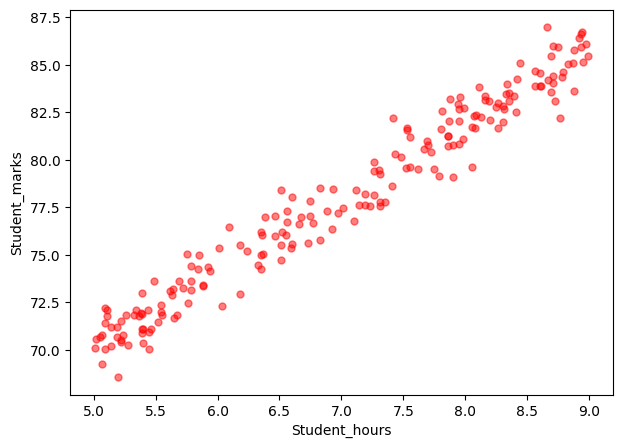

In [11]:
plt.figure(figsize=(7,5))
plt.scatter(x=df.study_hours,y=df.student_marks,color="red",marker=".",s=100,alpha=0.5)
plt.xlabel("Student_hours")
plt.ylabel("Student_marks")
plt.show()

In [16]:
df.isnull()

,study_hours,student_marks
0,False,False
1,False,False
2,True,False
3,False,False
4,False,False
...,...,...
195,False,False
196,False,False
197,False,False
198,False,False


In [12]:
df.isnull().sum()

study_hours      5
student_marks    0
dtype: int64

In [18]:
df.mean()

study_hours       6.995949
student_marks    77.933750
dtype: float64

In [14]:
df2=df.fillna(df.mean())
print(df2)

     study_hours  student_marks
0       6.830000          78.50
1       6.560000          76.74
2       6.995949          78.68
3       5.670000          71.82
4       8.670000          84.19
..           ...            ...
195     7.530000          81.67
196     8.560000          84.68
197     8.940000          86.75
198     6.600000          78.05
199     8.350000          83.50

[200 rows x 2 columns]


In [15]:
df.isnull().sum()

study_hours      5
student_marks    0
dtype: int64

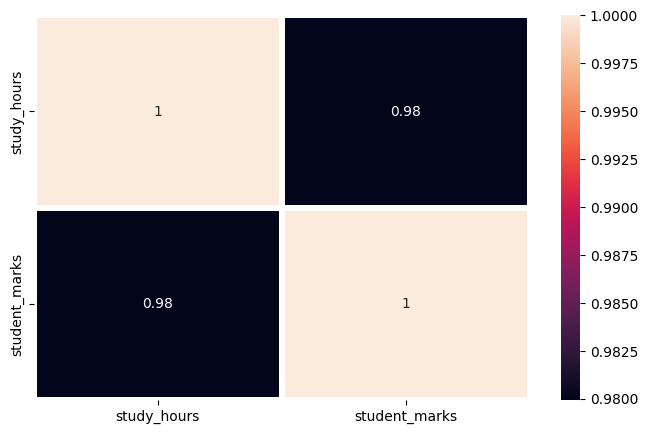

In [16]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(),annot=True,linewidths=3)
plt.show()

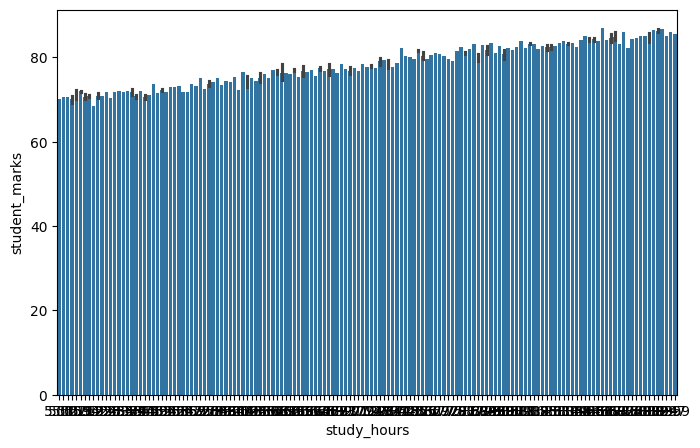

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(x="study_hours", y="student_marks", data=df2)
plt.show()



In [18]:
#split dataset
#matrix = X = Independent Variable = student_hours
#vector = y = Dependent Variable = student_marks

X=df2.drop("student_marks",axis="columns")
y=df2.drop("study_hours",axis="columns")
print("shape of X =",X.shape)
print("shape of y =",y.shape)

shape of X = (200, 1)
shape of y = (200, 1)


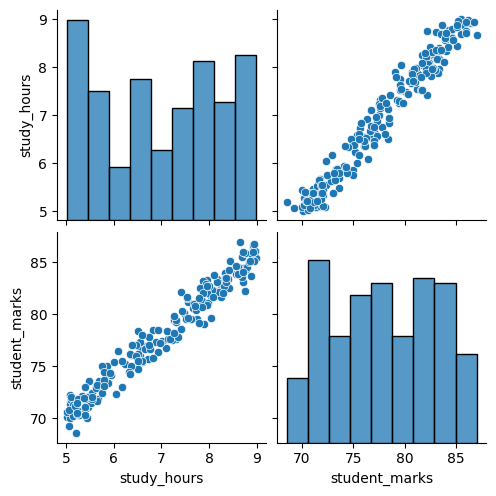

In [19]:
sns.pairplot(df)

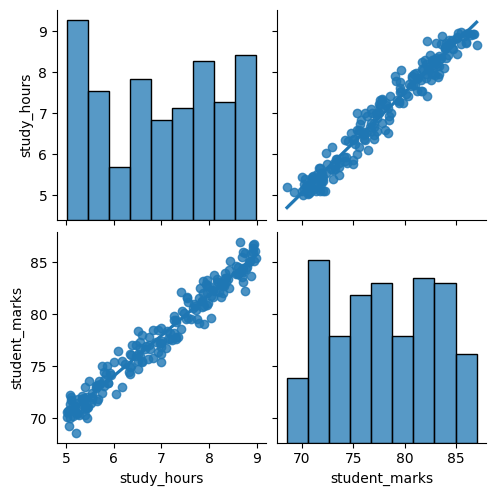

In [20]:
sns.pairplot(df2, kind='reg')

In [22]:
from sklearn.model_selection import train_test_split
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=51)
print("shape of X_train =", X_train.shape)
print("shape of Y_train =", y_train.shape)
print("shape of Y_train =", X_test.shape)
print("shape of Y_train =", y_test.shape)

shape of X_train = (160, 1)
shape of Y_train = (160, 1)
shape of Y_train = (40, 1)
shape of Y_train = (40, 1)


# Linear Regression Model

In [23]:
# y = mx+c
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [24]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
lr.coef_

array([[3.93571802]])

In [26]:
# value of c
lr.intercept_

array([50.44735504])

In [32]:
#subsyituting the value of m and c in the formula 
# y = m * x + c

m= 3.93571802
c= 50.44735504

y= m * 5 + c # here 5 is study hours. you can think so.
y

101.6116893

In [38]:
y_pred = lr.predict(X_test)
# print(X_test)
y_pred

array([[83.11381458],
       [78.9025963 ],
       [84.57003024],
       [85.82946001],
       [84.72745896],
       [80.75238377],
       [72.84159055],
       [71.66087515],
       [73.23516235],
       [71.66087515],
       [73.47130543],
       [76.38373677],
       [73.23516235],
       [73.58937697],
       [82.95638585],
       [70.40144538],
       [73.23516235],
       [78.74516758],
       [75.55723598],
       [82.68088559],
       [76.65923703],
       [70.48015974],
       [74.77009238],
       [77.98143645],
       [85.59331693],
       [82.56281405],
       [76.42309395],
       [85.0423164 ],
       [78.39095296],
       [81.38209865],
       [81.73631327],
       [83.15317176],
       [82.20859943],
       [81.10659839],
       [73.58937697],
       [71.1492318 ],
       [71.89701823],
       [81.53952737],
       [72.60544747],
       [71.93637541]])

In [37]:
pd.DataFrame(np.c_[X_test,y_test,y_pred],columns=["study_hours","student_marks_original Percentage","student_marks_predicted Percentage"])

,study_hours,student_marks_original Percentage,student_marks_predicted Percentage
0,8.300000,82.02,83.113815
1,7.230000,77.55,78.902596
2,8.670000,84.19,84.570030
3,8.990000,85.46,85.829460
4,8.710000,84.03,84.727459
5,7.700000,80.81,80.752384
6,5.690000,73.61,72.841591
7,5.390000,70.90,71.660875
8,5.790000,73.14,73.235162
9,5.390000,73.02,71.660875


In [39]:
lr.score(X_test, y_test)

0.9514124242154464

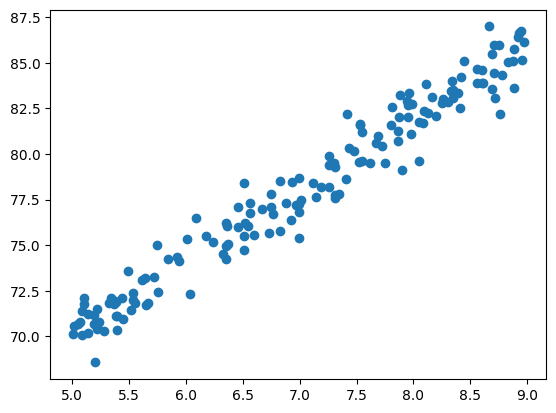

In [40]:
plt.scatter(X_train, y_train)

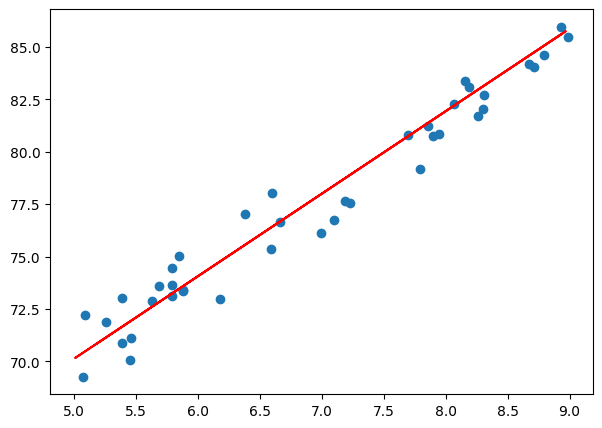

In [41]:
plt.figure(figsize=(7,5))
plt.scatter(X_test, y_test)
plt.plot(X_train,lr.predict(X_train),color="red")

In [42]:
import joblib
joblib.dump(lr, "Student_mark_prediction_model.pkl")

['Student_mark_prediction_model.pkl']

In [43]:
model = joblib.load("Student_mark_prediction_model.pkl")

In [44]:
model.predict([[10]])[0][0]

C:\Users\Parth Thakkar\anaconda3\envs\learning\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(89.80453520342567)

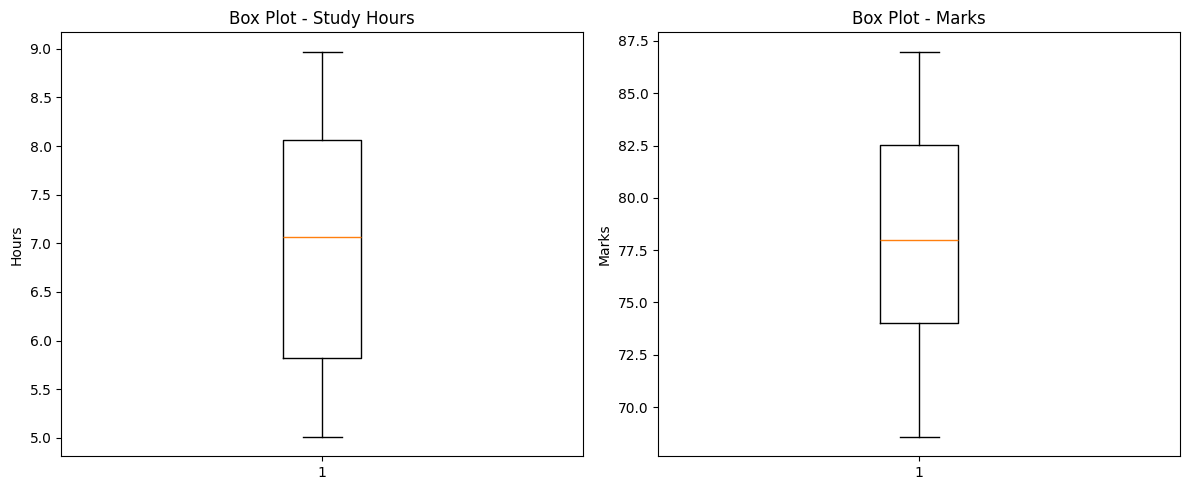

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Box plot - shows outliers as points beyond whiskers
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.boxplot(X_train)
plt.title('Box Plot - Study Hours')
plt.ylabel('Hours')

plt.subplot(1, 2, 2)
plt.boxplot(y_train)
plt.title('Box Plot - Marks')
plt.ylabel('Marks')

plt.tight_layout()
plt.show()